# **Predicting Stroke Risk based on Health and Demographic Factors**

**Team:** Ankita Lodh, Lakshya Sajal Kumar, Ayushi Mukherjee, Tanya Singh, Shivani Nadella

### **Spring 2026 Data Science Project**

# **Contributions**

Tanya (C, D, E, F):

*   Identified the averages and outliers for all features and entries in the dataset
*   Determined most important attributes for analysis
*   Coded and trained the ML model
*   Produced visualization of hyperplane decision boundary

Ayushi (C, G):

* Created two histograms for average glucose level among all individuals, separated by group (stroke vs. no stroke)
* Investigated whether those who had a stroke had higher than average glucose levels using Mann-Whitney test; rejected null hypothesis
* Wrote the introduction and the purpose of random forest and logistic regression in the final report

Ankita (B, D, E):

* Handled missing fields by replacing with mean (for BMI) and mode for groups based on gender and heart disease (for smoking status); ensured consistency in naming
* Suggested Random Forest + logistic regression for the ML approach
* Wrote the Random Forest and logistic regression test data analysis

Shivani (C, D, F, G):

*  Investigated whether those who had a stroke had different average BMIs across smoking status categories using Shapiro-Wilk test and Kruskal-Wallis test
*  Determined that there is no statistically significant difference between the median BMIs for the groups
* Wrote the primary analysis on why we chose classification and result analysis
* Wrote conclusion
* Created final github page

Lakshya (A, C, E, F):
*   Found the dataset
*   Wrote the intoduction for the EDA describing what variables were used and why certain steps were taken during the EDA
*   Investigated whether stroke occurrence was associated with hypertension
*   Performed a chi-squared test and rejected the null hypothesis
*   Wrote the insights and conclusion section

# **Introduction**

Dataset: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset

Citation: Fedesoriano. (2020). Stroke Prediction Dataset [Data set]. *Kaggle*. https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset


Stroke is one of the most serious global health problems. In 2021, stroke was the third leading cause of death and disability globally. According to the Centers for Disease Control and Prevention, someone in the United States has a stroke every 40 seconds, and approximately every 3 seconds, one person dies from a stroke. In addition, stroke reduces mobility in more than half of stroke survivors ages 65 and above. Stroke also imposes economic burdens due to costs of healthcare services, medicines to treat stroke, and absence from employment.

This project focuses on analyzing the Stroke Prediction Dataset (Fedesoriano, 2020), which includes a range of clinical and demographic features such as age, hypertension, work type, average glucose level, body mass index (BMI), and smoking status. These features are often associated with stroke risk and are studied to identify patterns for early detection and prevention of stroke.

The primary goal of our analysis was to examine the relationship between these features and stroke occurrence and to determine which features are the strongest predictors for stroke risk. Specifically, we aim to understand which health or demographic factors most significantly contribute to predicting stroke risk.

To address this question, we conducted hypothesis testing to evaluate the strength of age, average glucose level, and body-mass index as predictors for stroke likelihood. The testing revealed that these were statistically significant predictors. These results were confirmed by Random Forest, which identified these three features as the most important predictors for stroke likelihood.

Answering this question is important because most of these health factors, such as high blood pressure and high cholesterol levels, can be changed. By identifying the most important predictors, our analysis can inform meaningful lifestyle choices and provide insight into early diagnosis and treatment, therefore addressing the global concern for stroke.


# **Data Curation**
We started by replacing missing BMI fields with the mean BMI from the whole dataset. We also noticed that smoking status was “Unknown” for nearly ⅓ of the rows, which would make analysis difficult, so we used a grouping approach to group by gender and heart disease and find the respective modes of smoking status for each group. To maximize ease of analysis, we also replaced “Yes” and “No” for “ever_married” with 1 and 0 respectively. Finally, we made all column names lowercase to make column access uniform.


In [1]:
import warnings
# Ignore warnings related to future Pandas changes (eventual syntax recommendations)
warnings.simplefilter(action='ignore', category=FutureWarning)
# from google.colab import files
import pandas as pd
import numpy as np

df = pd.read_csv("healthcare-dataset-stroke-data.csv")

# I will prepare and clean the original dataset by converting to dataframe,
# handling missing data, converting data types, and renaming column
# names for consistency in capitalization.

# After each step, I will display the head of the dataframe.

# Replace missing BMIs with the mean BMI
mean_bmi = df["bmi"].mean()
df["bmi"].fillna(mean_bmi, inplace = True)
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1


In [2]:
# Check how many "Unknown" rows there are to determine how to handle
unknown_count = df["smoking_status"].value_counts().get("Unknown", 0)
print(unknown_count/len(df)) # as a proportion
# Because unknown is in nearly 1/3 of the dataframe's rows, we want to replace
# it (case by case) with data that makes sense

0.3021526418786693


In [3]:
# Group based on gender and heart disease, find mode for each category
# Similarly to in HW 3, replace each Unknown in a given category with the corresponding mode
df["smoking_status"] = df["smoking_status"].replace("Unknown", np.nan)

male_disease = (df["gender"] == "Male") & (df["heart_disease"] == 1)
male_disease_mode = df[male_disease]["smoking_status"].mode()[0]
df.loc[male_disease, "smoking_status"] = df[male_disease]["smoking_status"].fillna(male_disease_mode)

female_disease = (df["gender"] == "Female") & (df["heart_disease"] == 1)
female_disease_mode = df[female_disease]["smoking_status"].mode()[0]
df.loc[female_disease, "smoking_status"] = df[female_disease]["smoking_status"].fillna(female_disease_mode)

male_no_disease = (df["gender"] == "Male") & (df["heart_disease"] == 0)
male_no_disease_mode = df[male_no_disease]["smoking_status"].mode()[0]
df.loc[male_no_disease, "smoking_status"] = df[male_no_disease]["smoking_status"].fillna(male_no_disease_mode)

female_no_disease = (df["gender"] == "Female") & (df["heart_disease"] == 0)
female_no_disease_mode = df[female_no_disease]["smoking_status"].mode()[0]
df.loc[female_no_disease, "smoking_status"] = df[female_no_disease]["smoking_status"].fillna(female_no_disease_mode)

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1


In [4]:
# The "ever_married" column consists of Yes/No, so I will replace these with 1/0 respectively
df.loc[df["ever_married"] == "Yes", "ever_married"] = 1
df.loc[df["ever_married"] == "No", "ever_married"] = 0

# This will make it easier for us to analyze this column alongside other
# columns with 0/1 values, such as "hypertension" and "heart_disease."

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,1,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,1,Self-employed,Rural,202.21,28.893237,never smoked,1
2,31112,Male,80.0,0,1,1,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,1,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,1,Self-employed,Rural,174.12,24.000000,never smoked,1


In [5]:
# Enforce that all column names should be strictly lowercase for consistency
# Since "Residence_type" is the only name that doesn't follow this
df = df.rename(columns = {"Residence_type": "residence_type"})
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,1,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,1,Self-employed,Rural,202.21,28.893237,never smoked,1
2,31112,Male,80.0,0,1,1,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,1,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,1,Self-employed,Rural,174.12,24.000000,never smoked,1


In [7]:
df.to_csv("cleaned_stroke_dataset.csv", index = False) # saving new df for convenient access
# files.download("cleaned_stroke_dataset.csv")

# **Exploratory Data Analysis**

In this section, the cleaned stroke dataset was explored to understand the structure, distributions, and relationships between key variables prior to hypothesis testing. The dataset was loaded into a DataFrame named new_df, which includes variables such as stroke (target variable), bmi, avg_glucose_level, smoking_status, and hypertension. Missing values were handled during the data cleaning stage, particularly for variables like BMI, to ensure accurate analysis.

Both continuous variables (e.g., BMI and average glucose level) and categorical variables (e.g., smoking status and hypertension) were examined using summary statistics and visualizations such as histograms and bar charts. In certain analyses, the dataset was filtered to focus on specific groups, such as individuals who experienced a stroke (stroke == 1). This exploratory step was essential for identifying patterns, checking assumptions like normality, and selecting appropriate statistical tests, including parametric and non-parametric methods, for subsequent analysis.

In [8]:
# we will load our cleaned dataset into a new dataframe
new_df = pd.read_csv("cleaned_stroke_dataset.csv")

# we want to learn more about our dataset that we have first, before conducting hypothesis testing
# let's first check if our data has properly been cleaned by seeing if there is a deviation in the missing values
# additionally, we want to check if the type of the value is correct
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   int64  
 6   work_type          5110 non-null   object 
 7   residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 479.2+ KB


In [9]:
# now, let's find the summary statistics (count, mean, std, min, max, quartiles) of our dataset
new_df.describe()

,id,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,0.656164,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,0.475034,45.283560,7.698018,0.215320
min,67.000000,0.080000,0.000000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,0.000000,77.245000,23.800000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,1.000000,91.885000,28.400000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,1.000000,114.090000,32.800000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,1.000000,271.740000,97.600000,1.000000


**Characteristics and Observations:** As seen from the above output, a few characteristics are observed from the dataset we are about to use in our analysis for stroke prediction. Firstly, it is evident that we have properly cleaned our dataset. This is because there are no null/missing values since all of the column's non-null counts are equivalent. Additionally, we can notice that all of the values are numerical, except that of gender, work_type, residence_type, and smoking_status, which should be strings.

When it comes to the summary statistics, we can observe that in our dataset, the mean age of all the recorded people is 43.23 years old, with the youngest person being 0.08 years old and oldest being 82 years old. Additionally, we can observe that the mean glucose level is 106.15, with the lowest level being 55.12 and the highest level being 271.74. Lastly, we can also observe that the mean BMI is 28.89, with the minimum being 10.3 and the maximum being 97.6. For the rest of the columns, the summary statistics are irrelevant because either they are binary (0 and 1), or the id was recorded.

In [10]:
# lets count the number of features and entries
new_df.shape

(5110, 12)

**Features and Entries:** As seen above, there are a total of 12 features recorded in our dataset, with a total of 5110 entries. The features include id, gender, age, hypertension, heart_disease, ever_married, work_type, residence_type, avg_glucose_level, bmi, smoking_status, and stroke. The following is what we know about each feature:

*   id: unique identifier
*   gender: "Male", "Female" or "Other"
*   age: age of the patient
*   hypertension: 0 if the patient doesn't have hypertension, 1 if the patient has hypertension
*   heart_disease: 0 if the patient doesn't have any heart diseases, 1 if the patient has a heart disease
*   ever_married: 0 if not married, 1 if married
*   work_type: "children", "Govt_jov", "Never_worked", "Private" or "Self-employed"
*   residence_type: "Rural" or "Urban"
*   avg_glucose_level: average glucose level in blood
*   bmi: body mass index
*   smoking_status: "formerly smoked", "never smoked", or "smokes"
*   stroke: 1 if the patient had a stroke or 0 if not

Source: Fedesoriano. (2020). Stroke Prediction Dataset [Data set]. Kaggle. https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset



In [11]:
# we want to check which one of the cateogircal features are over-represented
# are there more of one gender?
display(new_df['gender'].value_counts())

# are there more of one work type?
display(new_df['work_type'].value_counts())

# are there more of one residence type?
display(new_df['residence_type'].value_counts())

# are there more of one smoking status?
display(new_df['smoking_status'].value_counts())

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

smoking_status
never smoked       3406
formerly smoked     915
smokes              789
Name: count, dtype: int64

**Over-representation:** From the output above, we can notice a few things about our dataset. Firstly, while there are more than 2000 entries for the "Male" or "Female" gender, there is only one entry for the "Other" category. Additionally, more entries are recorded from those who work in a private organization by a substantial amount compared to the rest of the work types, since there are 2925 private workers but less than 900 of each of the other types. This shows that the work in the private sector is over-represented in this dataset. Lastly, non-smokers have almost 2/3 of the entries, which also means that they are over-represented in this dataset.

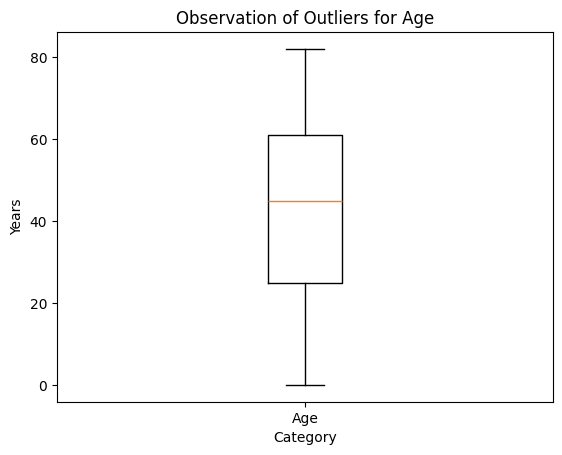

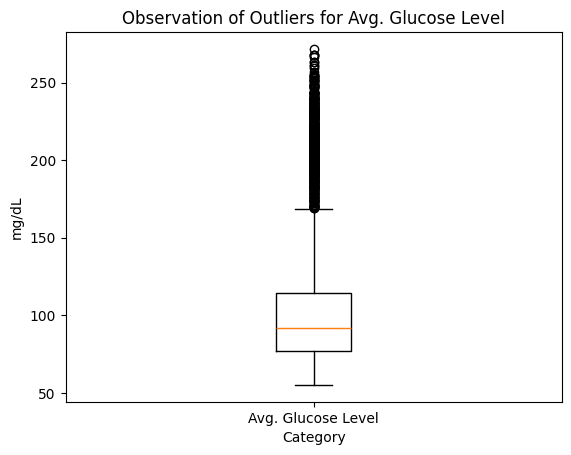

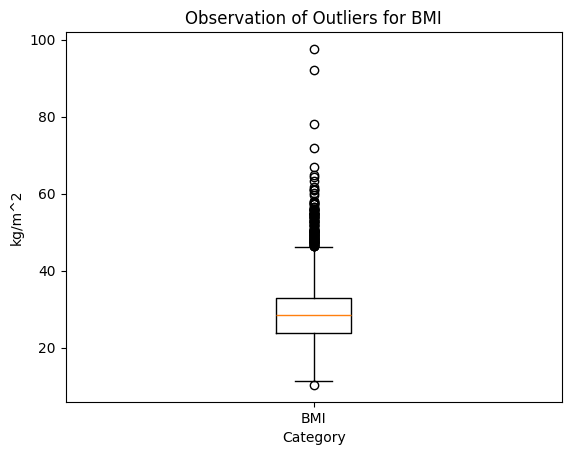

In [12]:
# now, we want to see if there are any outliers in our dataset in terms of age, avg_glucose_level, and bmi
# this is because these are the only numerical variables that are not binary
# best way to do this will be to see it in a boxplot (the outliers are dots)

import matplotlib.pyplot as plt

# for age
# reference: lec 8, slide 23
fig, ax = plt.subplots()
# makes the box plot
ax.boxplot(new_df['age'], tick_labels = ['Age'])
# labels
ax.set_xlabel('Category')
ax.set_ylabel('Years')
ax.set_title('Observation of Outliers for Age')
plt.show()

# for avg_glucose_level
# reference: lec 8, slide 23
fig1, ax1 = plt.subplots()
# makes the box plot
ax1.boxplot(new_df['avg_glucose_level'], tick_labels = ['Avg. Glucose Level'])
# labels
ax1.set_xlabel('Category')
ax1.set_ylabel('mg/dL')
ax1.set_title('Observation of Outliers for Avg. Glucose Level')
plt.show()

# for bmi
# reference: lec 8, slide 23
fig2, ax2 = plt.subplots()
# makes the box plot
ax2.boxplot(new_df['bmi'], tick_labels = ['BMI'])
# labels
ax2.set_xlabel('Category')
ax2.set_ylabel('kg/m^2')
ax2.set_title('Observation of Outliers for BMI')
plt.show()

**Analysis of Outliers:** As seen from the box-plots above, there are no outliers in terms of age in the dataset. However, there are a significant amount of outliers for the average glucose level and the BMI. As seen above, most of the outliers in both of these categories are normally larger, with the outliers for the BMI being more dispersed. However, there is one BMI of 10.3 that is an outlier on the lower end. For the purpose of this project, these values will not be removed due to two main reasons. Firstly, there are a significant amount of outliers. Secondly, these abnormal factors may have led to the stroke to begin with. Therefore, it is important to keep these values in our analysis.

**Hypothesis Testing**

**Attributes to Test:** Our analysis will mainly test if there is any relationship between a patient's Average Glucose Level, BMI, and diagnosis of Hypertension in the occurrence of a stroke. These attributes were chosen because they are common health factors that are often linked to stroke risk and overall cardiovascular health. By looking at them together, we hope to get a clearer idea of how these factors may be connected to the occurrence of a stroke.

**Question 1: Do individuals who had a stroke tend to have a higher average glucose level compared to those who did not have a stroke?**

Since we are comparing data between two groups, we need to use either a T-Test (if the distribution is normal) or a Mann-Whitney U Test (if the distribution is skewed/has outliers).

To determine which test to use, we need to first plot a histogram to check the distribution of the data.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

glucose_stroke = new_df[new_df['stroke'] == 1]['avg_glucose_level']
glucose_no_stroke = new_df[new_df['stroke'] == 0]['avg_glucose_level']

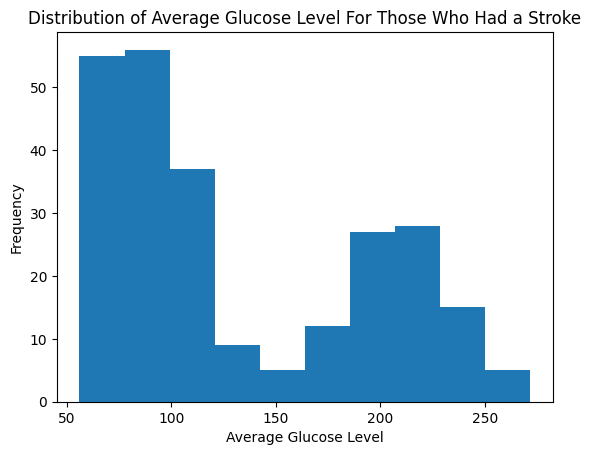

In [14]:
# Plotting the histogram for the mean glucose level of those who had a stroke

plt.hist(glucose_stroke)
plt.title("Distribution of Average Glucose Level For Those Who Had a Stroke")
plt.xlabel("Average Glucose Level")
plt.ylabel("Frequency")

# Show plot
plt.show()

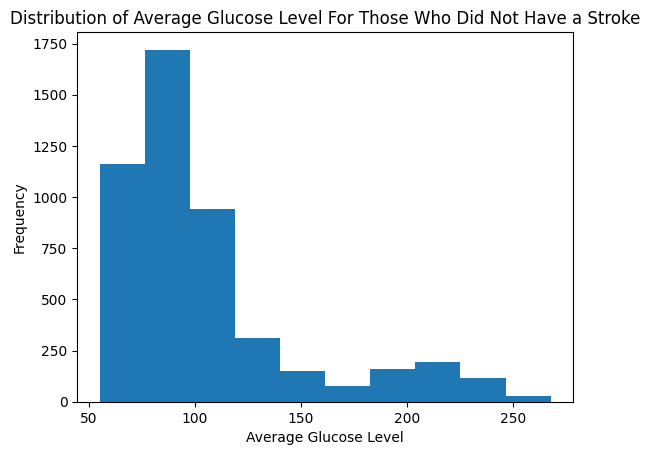

In [15]:
# Plotting the histogram for the mean glucose level of those who did not have a stroke

plt.hist(glucose_no_stroke)
plt.title("Distribution of Average Glucose Level For Those Who Did Not Have a Stroke")
plt.xlabel("Average Glucose Level")
plt.ylabel("Frequency")

# Show plot
plt.show()

**Attributes affecting analysis:**

We notice that all the histograms are skewed to the right. This supports that the data is not normal and requires non-parametric tests for analysis. Therefore, we will perform a Mann-Whitney U test.

Now, we determine our null and alternate hypothesis. (Assume $\alpha=0.05$)

> H$_0$ : The median glucose level for those who had a stroke is equal to the median glucose level for those who did not have a stroke.

Median Glucose Level$_{stroke}$ ​=Median Glucose Level$_{no stroke}$
> H$_a$ :  The median glucose level for those who had a stroke is greater than the median glucose level for those who did not have a stroke.

Now, let's perform the Mann-Whitney Test.

In [16]:
from scipy.stats import mannwhitneyu

res = mannwhitneyu(glucose_stroke, glucose_no_stroke, alternative="greater")

res.pvalue

np.float64(1.8201836355446622e-09)

**Mann-Whiteny p-value interpretation:**

We get a p-value of approximately 1.82 x $10^{-9}$, which is less than $\alpha=0.05$

Therefore, we **reject** our null hypothesis. There is statistically significant evidence to support our alternate hypothesis that individuals who had a stroke tend to have a higher median glucose level than though who did not have a stroke.

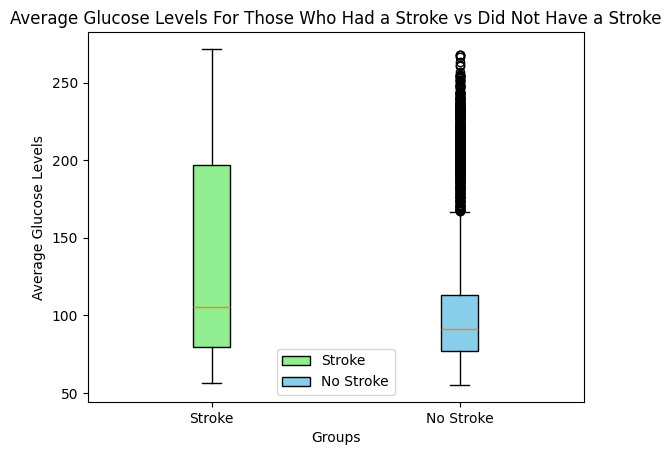

In [17]:
# Plot a boxplot
box = plt.boxplot(
    [glucose_stroke, glucose_no_stroke],tick_labels=["Stroke", "No Stroke"],
    patch_artist=True
)

# Color the boxes
box['boxes'][0].set_facecolor('lightgreen')
box['boxes'][1].set_facecolor('skyblue')

plt.title("Average Glucose Levels For Those Who Had a Stroke vs Did Not Have a Stroke")
plt.xlabel("Groups")
plt.ylabel("Average Glucose Levels")

# Simple legend
plt.legend(["Stroke", "No Stroke"])

plt.show()

From the box plot, we notice that the median for the "Stroke" group has a slightly higher median than that of the "No Stroke" group. This further proves  our conclusion from the hypothesis test that individuals who had a stroke tend to have a higher median glucose level than though who did not have a stroke.

**Question 2: Do individuals who suffered a stroke have different average BMIs across smoking categories?**


First we determine our null and alternate hypothesis. (Assume $\alpha=0.05$)

> H$_0$ :  There is no difference in the groups' median BMIs.

Median BMI$_{smokers}$ ​=Median BMI$_{never smokers}$ ​=Median BMI$_{former smokers}$

> H$_a$ : There is a difference in the groups' median BMIs.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# load our cleaned dataset into a new dataframe
new_df = pd.read_csv("cleaned_stroke_dataset.csv")

#isolate the dataframe to only individuals who have suffered a stroke
stroke_df = new_df[new_df['stroke'] == 1]
#bmis of the group of individuals who formerly smoked
bmi_former = new_df[(new_df['stroke'] == 1) &
 (new_df['smoking_status'] == 'formerly smoked')]['bmi']
#bmis of the group of individuals who never smoked
bmi_never = new_df[(new_df['stroke'] == 1) &
 (new_df['smoking_status'] == 'never smoked')]['bmi']
#bmis of the group of individuals who current smoke
bmi_smokes = new_df[(new_df['stroke'] == 1) &
 (new_df['smoking_status'] == 'smokes')]['bmi']



In [19]:
print("Testing for normality of the BMIs across the three groups")
from scipy import stats

print(stats.shapiro(bmi_former))
print(stats.shapiro(bmi_never))
print(stats.shapiro(bmi_smokes))


Testing for normality of the BMIs across the three groups
ShapiroResult(statistic=np.float64(0.9210027177418553), pvalue=np.float64(0.00017487815375835016))
ShapiroResult(statistic=np.float64(0.9080854687207409), pvalue=np.float64(1.78520786822663e-07))
ShapiroResult(statistic=np.float64(0.967286938347141), pvalue=np.float64(0.2669849457546159))


**Attributes affecting analysis:**

From the Shapiro-Wilk tests for normality, we observe the BMIs of the three groups of smokers who have suffered strokes are not normally distributed data. As the p-values of tests for the BMIs of the formerly smokers and never smokers are below the significance level of 0.05, they are not normally distributed data and we must use a non-parametric test for our analysis technique. The test for the third group of smokers has a p-value above the significance level of 0.05, so the data is normally distributed. Since most of the groups are not normally distributed, we will use a Kruskal-Wallis test to compare the medians of the three groups.


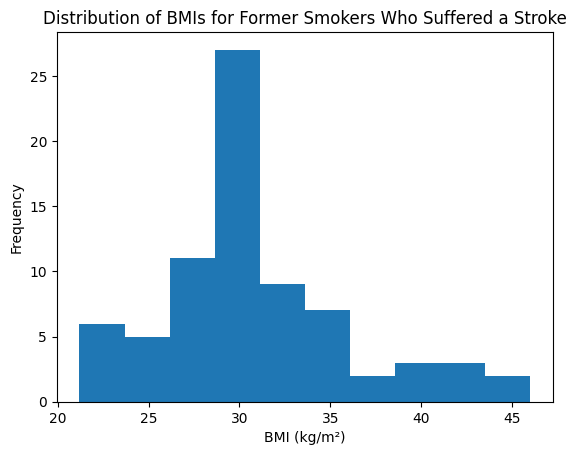

In [20]:
# Plotting the histogram for the BMIs of former smokers who suffered a stroke

plt.hist(bmi_former)
plt.title("Distribution of BMIs for Former Smokers Who Suffered a Stroke")
plt.xlabel("BMI (kg/m\u00b2)")
plt.ylabel("Frequency")

# Show plot
plt.show()

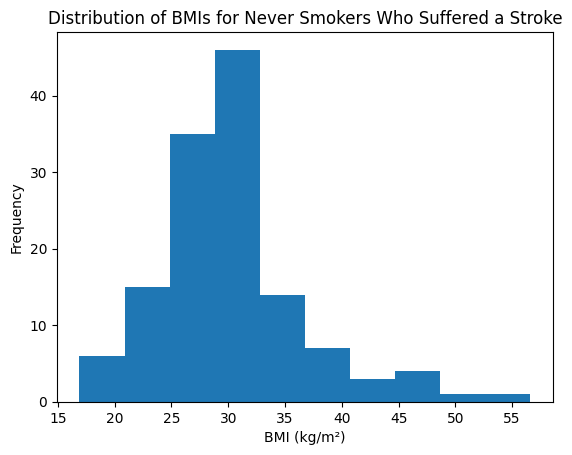

In [21]:
# Plotting the histogram for the BMIs of never smokers who suffered a stroke

plt.hist(bmi_never)
plt.title("Distribution of BMIs for Never Smokers Who Suffered a Stroke")
plt.xlabel("BMI (kg/m\u00b2)")
plt.ylabel("Frequency")

# Show plot
plt.show()

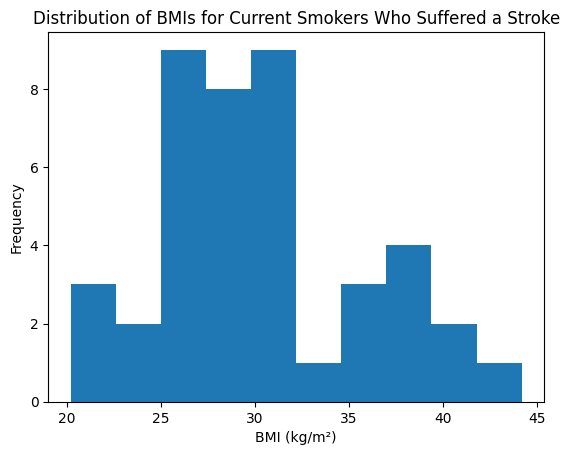

In [22]:
# Plotting the histogram for the BMIs of current smokers who suffered a stroke

plt.hist(bmi_smokes)
plt.title("Distribution of BMIs for Current Smokers Who Suffered a Stroke")
plt.xlabel("BMI (kg/m\u00b2)")
plt.ylabel("Frequency")

# Show plot
plt.show()

We notice that all the histograms are skewed to the right. This supports that the data is not normal and requires non-parametric tests for analysis.

In [23]:
#Perform a Kruskal-Wallis test
statistic, p_value = stats.kruskal(bmi_former, bmi_never, bmi_smokes)

print(f"The p-value is: {p_value:.4e}")

The p-value is: 3.9884e-01




**Kruskal-Wallis p-value interpretation**:

As the p-value of 0.39884 from the Kruskal Wallis test is greater than the significance level of 0.05, we fail to reject the null hypothesis. This supports the null hypothesis and that there is no statistically significant evidence that the median BMIs of the three smoker groups differs.

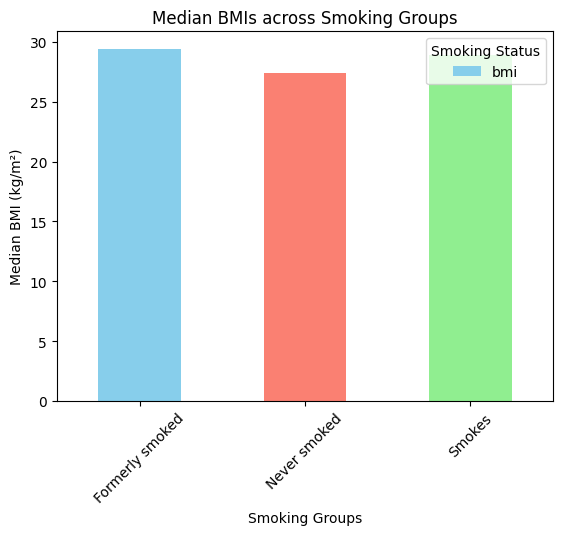

In [24]:
colors = ['skyblue', 'salmon', 'lightgreen', 'gold']

ax = new_df.groupby('smoking_status')['bmi'].median().plot(
    kind='bar',
    color=colors
)

plt.title('Median BMIs across Smoking Groups')
plt.xlabel('Smoking Groups')
plt.ylabel('Median BMI (kg/m\u00b2)')
ax.set_xticklabels([label.get_text().capitalize() for label in ax.get_xticklabels()],
                   rotation=45)
ax.legend(title='Smoking Status')

plt.show()

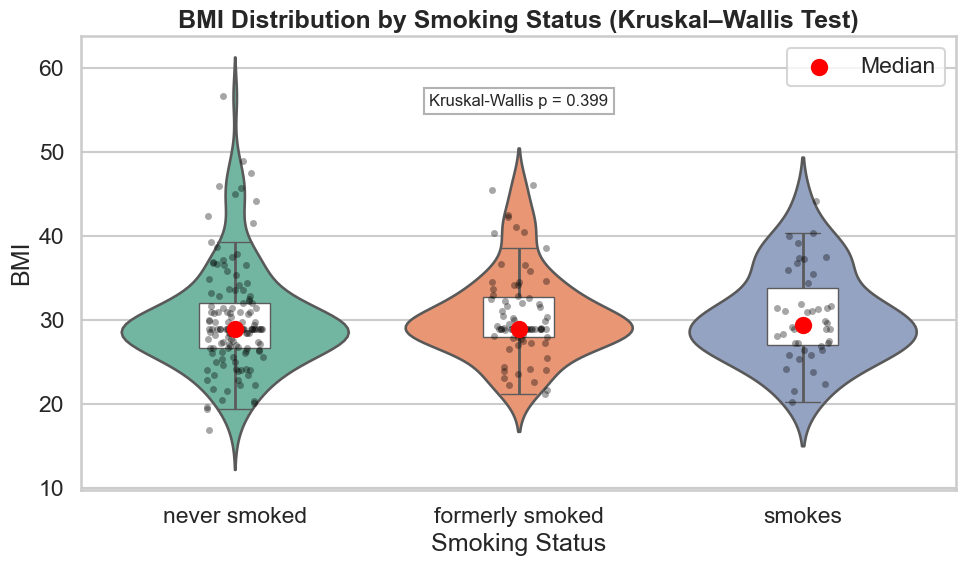

In [25]:
import seaborn as sns



df = stroke_df[["smoking_status", "bmi"]].dropna()

order = ["never smoked", "formerly smoked", "smokes"]
df = df[df["smoking_status"].isin(order)]

groups = [
    df[df["smoking_status"] == cat]["bmi"]
    for cat in order
]

stat, p = stats.kruskal(*groups)

sns.set(style="whitegrid", context="talk")
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="smoking_status",
    y="bmi",
    order=order,
    palette="Set2",
    inner=None
)

sns.boxplot(
    data=df,
    x="smoking_status",
    y="bmi",
    order=order,
    width=0.25,
    showcaps=True,
    boxprops={'facecolor':'white', 'zorder':3},
    showfliers=False,
    whiskerprops={'linewidth':2}
)

sns.stripplot(
    data=df,
    x="smoking_status",
    y="bmi",
    order=order,
    color="black",
    alpha=0.35,
    jitter=True
)

medians = df.groupby("smoking_status")["bmi"].median()

for i, cat in enumerate(order):
    plt.scatter(i, medians[cat], color="red", s=120, zorder=5, label="Median" if i == 0 else "")

plt.title("BMI Distribution by Smoking Status (Kruskal–Wallis Test)", weight="bold")
plt.xlabel("Smoking Status")
plt.ylabel("BMI")

plt.text(
    1,
    max(df["bmi"]) * 0.98,
    f"Kruskal-Wallis p = {p:.3f}",
    ha='center',
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray')
)

plt.legend()
plt.tight_layout()
plt.show()

From the violin plot, we notice that the median for all three groups are relatively similar. This further proves our conclusion from the hypothesis test that there is no statistically significant difference in the median BMIs of all three groups.

**Question 3: Is stroke occurrence associated with hypertension?**

First, we determine our null and alternate hypothesis. (Assume $\alpha=0.05$)

> H$_0$ : Hypertension and stroke occurrence are independent.

> H$_a$ : Hypertension and stroke occurrence are not independent.

Now, we perform a chi-squared test.

In [26]:
from scipy.stats import chi2_contingency

# Contingency table for hypertension and stroke
contingency_table = pd.crosstab(new_df["hypertension"], new_df["stroke"])
contingency_table

stroke,0,1
hypertension,,
0,4429,183
1,432,66


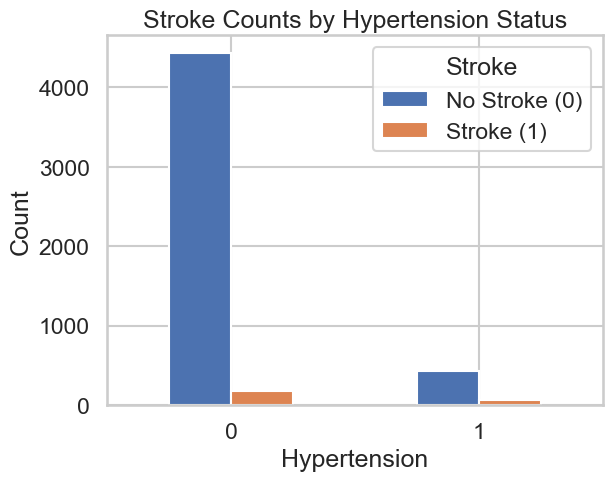

In [27]:
# Bar chart of raw counts
contingency_table.plot(kind="bar")

plt.title("Stroke Counts by Hypertension Status")
plt.xlabel("Hypertension")
plt.ylabel("Count")
plt.legend(title="Stroke", labels=["No Stroke (0)", "Stroke (1)"])
plt.xticks(rotation=0)

plt.show()

We observe that the number of stroke cases is higher among individuals with hypertension compared to those without hypertension.

In [28]:
# Perform chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-squared statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p)
print("Expected frequencies:")
print(expected)

Chi-squared statistic: 81.6053682482931
Degrees of freedom: 1
P-value: 1.661621901511823e-19
Expected frequencies:
[[4387.2665362  224.7334638]
 [ 473.7334638   24.2665362]]


**Attributes affecting the analysis:**

Since both hypertension and stroke occurrence are categorical variables, a Chi-squared test of independence is an appropriate method to assess their relationship.

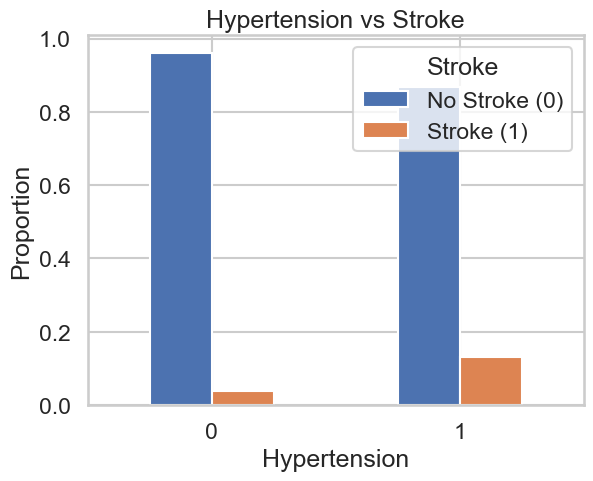

In [29]:
# Bar chart showing stroke proportions by hypertension status
proportions = contingency_table.div(contingency_table.sum(axis=1), axis=0)

proportions.plot(kind="bar")

plt.title("Hypertension vs Stroke")
plt.xlabel("Hypertension")
plt.ylabel("Proportion")
plt.legend(title="Stroke", labels=["No Stroke (0)", "Stroke (1)"])
plt.xticks(rotation=0)

plt.show()

In [30]:
# Stroke rate comparison
stroke_rate_no_htn = contingency_table.loc[0,1] / contingency_table.loc[0].sum()
stroke_rate_htn = contingency_table.loc[1,1] / contingency_table.loc[1].sum()

print("Stroke rate (no hypertension):", stroke_rate_no_htn)
print("Stroke rate (hypertension):", stroke_rate_htn)

Stroke rate (no hypertension): 0.03967909800520382
Stroke rate (hypertension): 0.13253012048192772


**Chi-Squared test p-value interpretation:**

The contingency table shows that 183 out of 4612 individuals without hypertension experienced a stroke, compared to 66 out of 498 individuals with hypertension. This corresponds to stroke rates of approximately 3.97% for individuals without hypertension and 13.25% for those with hypertension, which is more than three times higher.

The chi-squared test yields a statistic of 81.61 with a p-value of 1.66 × 10⁻¹⁹, which is far below the significance level of 0.05. Therefore, we reject the null hypothesis and conclude that hypertension and stroke occurrence are not independent.

Both the count-based and proportion-based bar charts reinforce this result, showing a clearly higher proportion of stroke cases among individuals with hypertension. Overall, there is strong statistical and visual evidence that hypertension is significantly associated with an increased likelihood of stroke.

**Result analysis from the hypothesis tests:**

Overall, the hypothesis testing helped identify which health-related features appear to be the most important in understanding stroke risk within the dataset. Among the variables analyzed, average glucose level and hypertension showed the strongest relationships with stroke occurrence. Using the Mann-Whitney U test, we found statistically significant evidence (p = 1.82 × 10⁻⁹) that individuals who experienced a stroke tended to have higher average glucose levels than those who did not. Similarly, the Chi-squared test of independence revealed a strong association between hypertension and stroke occurrence (χ² = 81.61, p = 1.66 × 10⁻¹⁹), with individuals diagnosed with hypertension experiencing strokes at a much higher rate. These findings suggest that both glucose level and hypertension may play an important role in predicting or explaining stroke risk, making them key features for future analysis and potential predictive modeling. On the other hand, the Kruskal-Wallis test found no statistically significant difference in BMI across smoking-status groups among stroke patients (p = 0.39884), suggesting that this relationship may be less influential in our analysis. Based on these results, hypertension and average glucose level were identified as potential prominent features for our analysis as they demonstrated strong associations with stroke occurrence.

# **Primary Analysis**

**Why Classification?**

We chose to use a classification machine learning approach because our main objective is to predict whether a person will have a stroke or not, and our target variable is binary (1 = stroke predicted, 0 = no stroke predicted). Our focus is to train our model to learn each class’ characteristics from a labelled input dataset and then predict the stroke class of new, unseen data. The dataset has labelled numerical and categorical features, including age, BMI, glucose levels, gender, and lifestyle factors, which are appropriate for classification models to handle. Classification algorithms such as logistic regression, decision trees, and random forest are well-suited to handle such mixed data types and predict classes based on these features. Additionally, classification models can also assess feature importance and predicted probabilities of the classifications for us to better understand the factors most strongly associated with stroke risk and make more informed conclusions about predictions.


**Why Random Forest?**

Our goal was to understand the feature importance and identify which features are the strongest predictors of stroke risk. We chose to use Random Forest Classifier for this because it provides us with feature importance scores, allowing us to identify the influence of each feature on the prediction. Since stroke prediction is a classification task, a classification model is the best option to match our output. Additionally, Random Forest can also capture the non-linear relationships between the different health and demographic factors, such as age, BMI, average glucose level, and heart disease, making it well-suited for this medical data.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# initializing X and Y
# id and stroke are not features to train the model on
# ref: HW4 2.2
X = new_df.drop(columns = ['id', 'stroke'])
Y = new_df['stroke'].astype(int)

# ref: lec 13, slide 26-27
# use one-hot encoding to create numeric features
X = pd.get_dummies(X, columns=["gender", "residence_type", "work_type", "smoking_status"])

# ref: HW4 2.2
seed = 42
test_size = 0.2

# split the data 0.8 and 0.2 for train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = test_size, random_state = seed)

# normalizing the train and test sets
s = StandardScaler()
# ref: lec 18, slide 31
X_train_scaled = s.fit_transform(X_train)
X_test_scaled = s.transform(X_test)

model = RandomForestClassifier(random_state = seed)

# ref: HW4 4.1
np.random.seed(seed)
# ref: lec 16, slide 46
model.fit(X_train_scaled, y_train)

# prints the accuracy of the Random Forest model
# also displays the classification report of the model
# ref: lec 12, slide 50
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Random Forest: {accuracy:.3f}")
print(classification_report(y_test, y_pred, target_names=['Bad Rating (False)', 'Good Rating (True)']))

# displays all the feature importances
# ref: HW4 5.1
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by = 'Importance', ascending = False)

# this shows the top 5 important features
print("Feature Importances:")
print(feature_importance_df[:5])

Accuracy of Random Forest: 0.939
                    precision    recall  f1-score   support

Bad Rating (False)       0.94      1.00      0.97       960
Good Rating (True)       0.00      0.00      0.00        62

          accuracy                           0.94      1022
         macro avg       0.47      0.50      0.48      1022
      weighted avg       0.88      0.94      0.91      1022

Feature Importances:
             Feature  Importance
4  avg_glucose_level    0.273913
0                age    0.241790
5                bmi    0.228814
1       hypertension    0.028308
2      heart_disease    0.024642


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

**Random Forest Analysis:**

Based on the classification report, precision was 94%, and recall was 100%. In general, recall is the most important measure for this application since in a healthcare context, it is critical to minimize false negatives (i. e., not miss any occurrences of stroke). A precision rate of 94% also strongly suggests that there were very few false positives, which means that the model struck a balance between excess flagging and excessive caution. Based on the results for feature importance, we can see that age, average glucose level, and BMI were the three most important determining features for predicting stroke. This was supposed by our hypothesis testing as well.

Now, we will conduct logistic regression to predict the likelihood of stroke based on age, average glucose level, and BMI.

**Why Logistic Regression?**

Since logistic regression is used as a classification model to predict probability of binary outcomes, we use logistic regression to estimate the likelihood of stroke based on age, BMI, and average glucose level. Logistic regression is also efficient in its interpretability, allowing us to understand how each feature contributes to stroke risk. In addition, since our dataset was imbalanced, we used `class_weight = 'balanced'` to give proper importance to the minority class.

In [32]:
# now, we will use the age, glucose level, and bmi as determining features
# ref: HW4 2.2
X = new_df[['age', 'avg_glucose_level', 'bmi']]
Y = new_df['stroke'].astype(int)

# split the data 0.8 and 0.2 for train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = test_size, random_state = seed)

# ref: HW4 3.1
# got warnings without the class_weight arg
# this is because there were not many people that had a stroke compared to those that did not
# ref: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
model = LogisticRegression(random_state=seed, max_iter = 1000, class_weight = 'balanced')

# ref: HW4 4.1
np.random.seed(seed)
model.fit(X_train, y_train)

# prints the accuracy of the Logistic Regression model
# also displays the classification report of the model
# ref: lec 12, slide 50
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Logistic Regression: {accuracy:.3f}")
print(classification_report(y_test, y_pred, target_names=['Bad Rating (False)', 'Good Rating (True)']))

Accuracy of Logistic Regression: 0.745
                    precision    recall  f1-score   support

Bad Rating (False)       0.98      0.74      0.84       960
Good Rating (True)       0.17      0.81      0.28        62

          accuracy                           0.74      1022
         macro avg       0.58      0.77      0.56      1022
      weighted avg       0.93      0.74      0.81      1022



**Logistic Regression Analysis:**

An accuracy of 74.5% indicates that logistic regression performed slightly worse than Random Forest did. Additionally, while precision was strong (98%), recall suffered, which suggests that logistic regression struggled to handle class imbalance due to its “linear” nature of creating a strict hyperplane. In contrast, Random Forest uses a sophisticated sequence of if-then logic to produce predictions, which allows for more flexibility.

In [33]:
# now we can use our trained model to predict stroke risk
def predict_risk(age, avg_glucose_level, bmi):
    # this is the user input
    input_df = pd.DataFrame({
        "age": [age],
        "avg_glucose_level": [avg_glucose_level],
        "bmi": [bmi]
    })
    # this is just predict
    # ref: HW4 4.1
    pred = model.predict(input_df)

    # this just reprints what the user put in
    print("User Input:")
    print("Age:", age)
    print("Average Glucose Level:", avg_glucose_level)
    print("BMI:", bmi)

    # this is just saying if there is a high or low stroke risk
    if pred[0] == 1:
        print("\nResult: High Stroke Risk\n")
    else:
        print("\nResult: Low Stroke Risk\n")

# demo
predict_risk(age = 67, avg_glucose_level = 228.69, bmi = 36.6)

predict_risk(age = 40, avg_glucose_level = 288.9, bmi = 25)

User Input:
Age: 67
Average Glucose Level: 228.69
BMI: 36.6

Result: High Stroke Risk

User Input:
Age: 40
Average Glucose Level: 288.9
BMI: 25

Result: Low Stroke Risk



**Purpose of predict_risk() Function:**

We implemented predict_risk() in order to test the logistic regression model with various inputs. The predict_risk() function takes in a person’s age, average glucose level, and BMI, displays that input, and finally predicts and outputs whether stroke risk is likely to be high (1) or low (0). This is a good proof-of-concept tool for showing the functionality of the model and for identifying cases for which the model performs poorly. For example, it is possible to “stress-test” the model by passing in information with unrealistic bounds to see how the model behaves in terms of stability.

# **Visualization**

Since a logistic regression model was used in order to predict stroke risk, it was important to visualize the decision boundary in which this model was trained on. So, using the model coefficients and the intercept, the decision boundary was plotted along with the specific data points of every person's age, glucose level, and BMI. As seen below, a 3D plot was used due to the use of these three most important features. Therefore, the decision boundary is a 2D plane. Additionally, it can be seen that the model will not be exactly precise, since a lot of non-stroke data points are present in the boundary where stroke is more likely. However, most of the stroke patients were in the correct boundary.

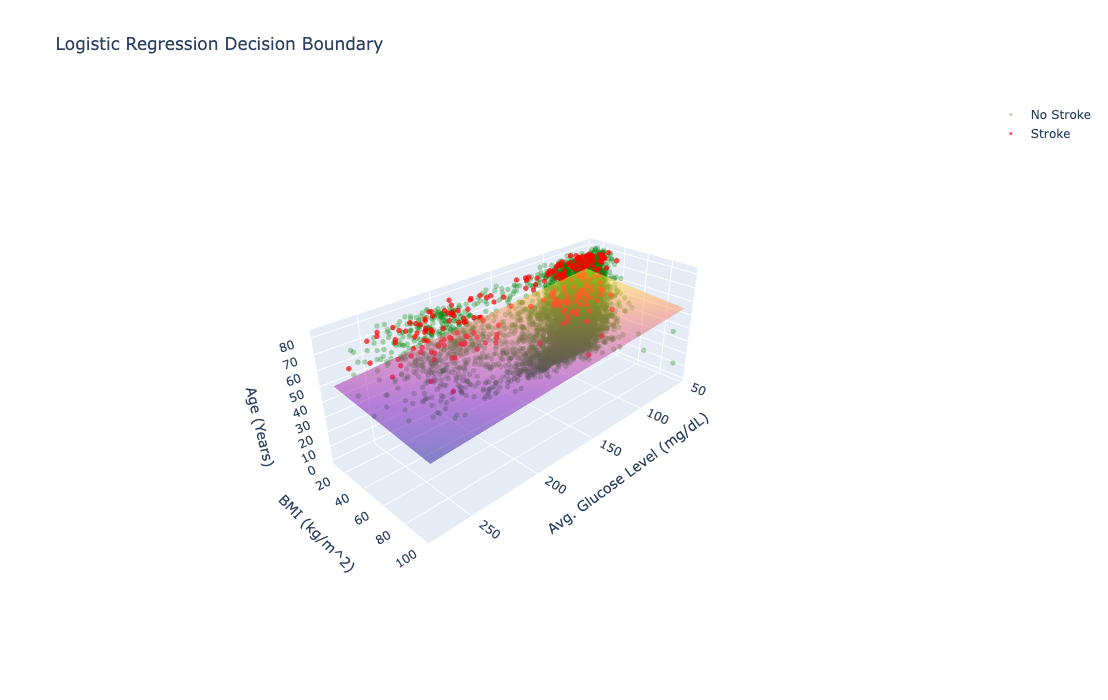

In [39]:
import plotly.graph_objects as go

# ref: HW4 6.2.3
def visualize_3d_plotly_interactive(X, Y, model):

    # ref: HW5 4.1
    glucose_values = np.linspace(X["avg_glucose_level"].min(), X["avg_glucose_level"].max(), 100)
    bmi_values = np.linspace(X["bmi"].min(), X["bmi"].max(), 100)

    # ref: https://numpy.org/doc/2.3/reference/generated/numpy.meshgrid.html
    # makes the values into tuples
    glucosev, bmiv = np.meshgrid(glucose_values, bmi_values)

    # solving for the decision boundary
    # since it is 3d, the model coeficients and interecept are stored in
    # the .coef_ and .intercept_ variables
    # ref: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
    agev = -((model.coef_[0][1] * glucosev + model.coef_[0][2] * bmiv + model.intercept_[0]) / model.coef_[0][0])

    # ref: HW4 6.2.3
    fig = go.Figure()

    # plotting the points without stroke
    fig.add_trace(go.Scatter3d(
        x = X[Y == 0]['avg_glucose_level'],
        y = X[Y == 0]['bmi'],
        z = X[Y == 0]['age'],
        mode = 'markers',
        marker = dict(size = 3, color = 'green', opacity = 0.3),
        name = 'No Stroke'
    ))

    # plotting the points with stroke
    fig.add_trace(go.Scatter3d(
        x = X[Y == 1]['avg_glucose_level'],
        y = X[Y == 1]['bmi'],
        z = X[Y == 1]['age'],
        mode = 'markers',
        marker = dict(size = 3, color = 'red', opacity = 0.7),
        name = 'Stroke'
    ))

    # plotting the decision boundary
    # ref: https://plotly.com/python/3d-surface-plots/
    fig.add_trace(go.Surface(
        x = glucosev,
        y = bmiv,
        z = agev,
        name = 'Decision Boundary',
        opacity = 0.5,
        # was getting a bar on the side that was not necessary
        showscale = False
    ))

    # updating the layout
    fig.update_layout(
        title = 'Logistic Regression Decision Boundary',
        scene = dict(
            xaxis_title = 'Avg. Glucose Level (mg/dL)',
            yaxis_title = 'BMI (kg/m^2)',
            zaxis_title = 'Age (Years)',
            camera = dict(
                eye = dict(x = 2.0, y = 2.0, z = 1.5)
            )
        ),
        width = 900,
        height = 700,
        showlegend = True
    )

    fig.show()

visualize_3d_plotly_interactive(X, Y, model)

# **Insights and Conclusions**

After reading through the project, an uninformed reader would likely come away with a clear and structured understanding of stroke risk and the key health and demographic factors associated with it. The project is organized in a logical progression, beginning with data cleaning and preparation, followed by exploratory data analysis, hypothesis testing, and finally machine learning modeling. This step by step flow allows the reader to build knowledge gradually, making complex concepts such as non parametric testing, feature importance, and classification models easier to follow. The use of both visualizations and statistical results further strengthens this understanding by providing both intuitive and quantitative evidence for each conclusion.

For a reader who is already familiar with the topic, the project still offers meaningful value by combining multiple analytical approaches to reinforce key findings. The consistency between hypothesis testing results and machine learning outputs, particularly the identification of age, average glucose level, and BMI as major predictors, adds depth and credibility to the analysis. Additionally, the comparison between Random Forest and logistic regression provides insight into how different models perform on imbalanced healthcare data, highlighting the importance of evaluation metrics such as recall in real world applications.

At the same time, the project also reveals certain limitations that deepen the reader’s understanding. For instance, the class imbalance in the dataset impacts model performance, especially in detecting stroke cases, which is a critical consideration in healthcare prediction tasks. The fact that one model achieves high accuracy but fails to correctly predict stroke cases emphasizes the need to look beyond accuracy as a metric. Overall, the project not only informs readers about stroke risk factors but also demonstrates how data science methods can be applied, evaluated, and critically interpreted, making it valuable for both beginners and more experienced audiences.

In conclusion, we demonstrated a complete machine learning pipeline and statistical analysis to predict stroke risk using health and demographic data in this project. Beginning with data cleaning and preprocessing, we handled missing values, standardized features, and prepared categorical variables for analysis. Through exploratory data analysis and hypothesis testing, we investigated relationships between stroke occurrence and several factors such as average glucose level and BMI. Using both Random Forest and Logistic Regression models, we evaluated different approaches for predicting stroke risk and identifying the most influential predictors, finding age, average glucose level, BMI, and hypertension as some of the strongest indicators of stroke likelihood. The hypothesis tests confirmed significant relationships between stroke risk and both glucose level and hypertension. With these factors, we generated a 3D visualization of how the logistic regression model uses age, average glucose level, and BMI together to classify individuals with higher and lower stroke risk. Though there’s some overlap between stroke and non-stroke cases due to the model’s linear decision boundary, the graph highlights meaningful patterns and helps understand the model’s predictions. Overall, the project shows that combining statistical analysis with machine learning can provide valuable insights that may contribute to earlier intervention and improved healthcare outcomes.
Thank you for reading our project and exploring these findings with us.

